In [5]:
#!/usr/bin/env python3
import re, string, time
import numpy
import matplotlib.pyplot as plt
import argparse

#header1=re.compile('^\s*(\w+)\s*(\w+)\s*#(\w+)\s*\,\s*(\w+)\s*(\d+)\s*(\d+)\s*(\d+)',re.I)
## header1=re.compile('^\s*(\w+)\s*([a-zA-Z0-9\/]+)\s*([#\d]+).*?\s*(\d+)\s*(\d+)\s*$',re.I)
header1=re.compile('^\s*(.*)\s+(\d+)\s+(\d+)\s*$',re.I)
header2=re.compile('^\s*(\S+)\s*(\S+)\s*(\S+)\s*(\S+)\s*(\S+)')

class geqdsk:
    """
    Turns the content of a GEQDSK file into a object
    Among the members of the gedsk class are grid dimensions, global
    quantities (current, magnetic field on axis, etc.), radial profiles
    (poloidal current function, pressure, etc.), the poloidal flux on the
    (R,Z) uniform grid, as well as the geometry of the boundary wall and
    limiter.

    For additional information about the content of the geqdsk file refer
    to the "G EQDSK FORMAT" document by Lang Lao.

   A. Pletzer July 17 2000, update by Feng Wang 2022-1-25
    """
    def __init__(self, file):
        f = open(file, 'r',encoding='utf-8')
        self.file=file
        thisLine=f.readline()
        pat=header1.match(thisLine)
        try:
            self.header=pat.group(1)
            self.nw=int(pat.group(2)) # r grid size
            self.nh=int(pat.group(3))

        except:
            print('error while reading line \n',thisLine)
        print('head:',self.header,'nw=',self.nw,'nh=',self.nh)
        thisLine = f.readline()
        thisLine = re.sub('([^Ee])-', '\\1 -', thisLine) # separate fields
        pat=header2.match(thisLine)
        try:
            self.rdim=float(pat.group(1))
            self.zdim=float(pat.group(2))
            self.rcentr=float(pat.group(3))
            self.rleft=float(pat.group(4))
            self.zmid=float(pat.group(5))
        except:
            print('error while reading line 1\n',thisLine)
        
        thisLine = f.readline()
        thisLine = re.sub('([^Ee])-', '\\1 -', thisLine) # separate fields
        pat=header2.match(thisLine)
        try:
            self.rmaxis=float(pat.group(1)) # magnetic axis position
            self.zmaxis=float(pat.group(2)) 
            self.psimag=float(pat.group(3)) # poloidal flux on mag. axis
            self.psibdy=float(pat.group(4)) # poloidal flux on last closed surface
            self.bcentr=float(pat.group(5)) # B at the geometry centre
        except:
            print('error while reading line 2\n',thisLine)
            
        thisLine = f.readline()
        thisLine = re.sub('([^Ee])-', '\\1 -', thisLine) # separate fields
        pat=header2.match(thisLine)
        try:
            self.currentA=float(pat.group(1)) # total current in Amps
        except:
            print('error while reading line 3\n',thisLine)

        thisLine = f.readline()

        # read remaining lines

        lines = f.read()
        lines = re.sub('\n', ' ', lines) # merge
        lines = re.sub('(\d)\-', '\\1 -', lines) # add space between numbers
        fields =  re.split('\s+', lines)
        numbers = []
        for n in fields:
            try:
                numbers.append(float(n))
            except:
                pass

        nw = self.nw
        nh = self.nh
        self.fpol   =numbers[0   :  nw]
        self.pres   =numbers[  nw:2*nw]
        self.ffprime=numbers[2*nw:3*nw]
        self.pprime =numbers[3*nw:4*nw]
        ia = 4*nw
        self.psirz = numpy.zeros([self.nw,self.nh])

        for ir in range(nw):
            self.psirz[ir,:]=numbers[ia:ia+nh]
            ia = ia + nw

        self.psirz_1=numpy.zeros([self.nw,self.nh])

        for ir in range(nw):
            for iz in range(nh):
                self.psirz_1[ir,iz] = self.psirz[iz,ir]

        self.qpsi   =numbers[ia:ia+nw]
        ia = ia + nw
        self.nbbbs  =int(numbers[ia])
        ia = ia + 1
        self.limitr =int(numbers[ia])
        ia = ia + 1
        self.rbbbs=[]
        self.zbbbs=[]
        for i in range(self.nbbbs):
            self.rbbbs.append(numbers[ia  ])
            self.zbbbs.append(numbers[ia+1])
            ia = ia + 2
        self.rlim=[]
        self.zlim=[]
        for i in range(self.limitr):
            self.rlim.append(numbers[ia  ])
            self.zlim.append(numbers[ia+1])
            ia = ia + 2

    def getPlasmaGeometry(self):
        """ return plasma boundary coordinates as [[r1,z1], [r2,z2],...] list """
        res=[]
        for i in range(self.nbbbs):
            res.append((self.rbbbs[i], self.zbbbs[i]))
        return res

    def getLimiterGeometry(self):
        """ return limiter geometry """
        res=[]
        for i in range(self.limitr):
            res.append((self.rlim[i], self.zlim[i]))
        return res
        
    def plot(self, what="all"):
        # default sizes
        plt.rc('font',size=16)
        plt.rcParams['figure.figsize']=(10,8)
        # plt.rcParams['text.usetex']=True
        R=numpy.linspace(self.rleft,self.rleft+self.rdim,self.nw)
        Z=numpy.linspace(self.zmid-0.5*self.zdim,self.zmid+0.5*self.zdim,self.nh)  
        R2D,Z2D = numpy.meshgrid(R,Z)
        fig =  plt.figure()
        ax = fig.add_subplot(121)
        cf = ax.contour(R2D,Z2D,self.psirz,50)
        fig.colorbar(cf)
        ax.plot(self.rbbbs,self.zbbbs,'r.--',markersize=6)
        ax.set_aspect('equal')
        ax.set_xlabel('$R$ (m)')
        ax.set_ylabel('$Z$ (m)')

        ax=fig.add_subplot(222)
        psi1d=numpy.linspace(0,1,self.nw)
        ax.plot(psi1d,self.qpsi)
        ax.set_ylabel('$q$')

        ax=fig.add_subplot(224)
        ax.plot(psi1d,self.pres)
        ax.set_ylabel('$P$ (Pa)')
        ax.set_xlabel('$\psi$')
        ax.ticklabel_format(style='sci',scilimits=(-1,2),axis='y')
        plt.savefig(self.file+'.png')
        plt.show()


    def toDX(self, filename):
        f = open(filename, 'w')
        date = time.ctime( time.time() )
        f.write('# DX format \n')
        f.write('# '+date+'\n')
        f.write('# the regular positions \n')
        line = "object 1 class gridpositions counts %d %d \n" % (self.nw, self.nh)
        f.write(line)
        rmin, zmin = self.rcentr-self.rdim/2., self.zmid-self.zdim/2.
        rmax, zmax = self.rcentr+self.rdim/2., self.zmid+self.zdim/2.
        delr, delz = (rmax-rmin)/(self.nw-1), (zmax-zmin)/(self.nh-1)
        line = "origin %15.6e %15.6e  \n" % (rmin, zmin)
        f.write(line)
        line = "delta %15.6e %15.6e  \n" % (delr, 0.)
        f.write(line)
        line = "delta %15.6e %15.6e  \n" % (0.  , delz)
        f.write(line)
        f.write("# object 2 are the regular connections \n")
        line = "object 2 class gridconnections counts %d %d \n" % (self.nw, self.nh)
        f.write(line)
        line = "object 3 class array type float rank 0 items %d  data follows  \n" % (self.nw*self.nh)
        f.write(line)
        for i in range(self.nw):
            for j in range(self.nh):
                f.write('%15.6e \n' % self.psirz[j][i])        
                f.write('attribute "dep" string "positions" \n')
                f.write('object "regular positions regular connections" class field \n')
                f.write('component "positions" value 1 \n')
                f.write('component "connections" value 2 \n')
                f.write('component "data" value 3 \n')
                f.write('end \n')
        f.close()
        

##############################################################################


 

head: EFITD    12/10/2013    #100000  5244msiter#701   0 nw= 129 nh= 129

    Turns the content of a GEQDSK file into a object
    Among the members of the gedsk class are grid dimensions, global
    quantities (current, magnetic field on axis, etc.), radial profiles
    (poloidal current function, pressure, etc.), the poloidal flux on the
    (R,Z) uniform grid, as well as the geometry of the boundary wall and
    limiter.

    For additional information about the content of the geqdsk file refer
    to the "G EQDSK FORMAT" document by Lang Lao.

   A. Pletzer July 17 2000, update by Feng Wang 2022-1-25
    
g-function
[46.8966478, 47.0290126, 47.1386964, 47.2340191, 47.3209061, 47.402395, 47.4799801, 47.5544046, 47.626084, 47.6952421, 47.7617094, 47.8248519, 47.8841961, 47.9398723, 47.9922833, 48.0417825, 48.0886662, 48.1331867, 48.1755721, 48.2161832, 48.2559425, 48.2961608, 48.3375749, 48.3800912, 48.423346, 48.4670431, 48.5109652, 48.5548972, 48.5984048, 48.6403973, 48.6786294, 48

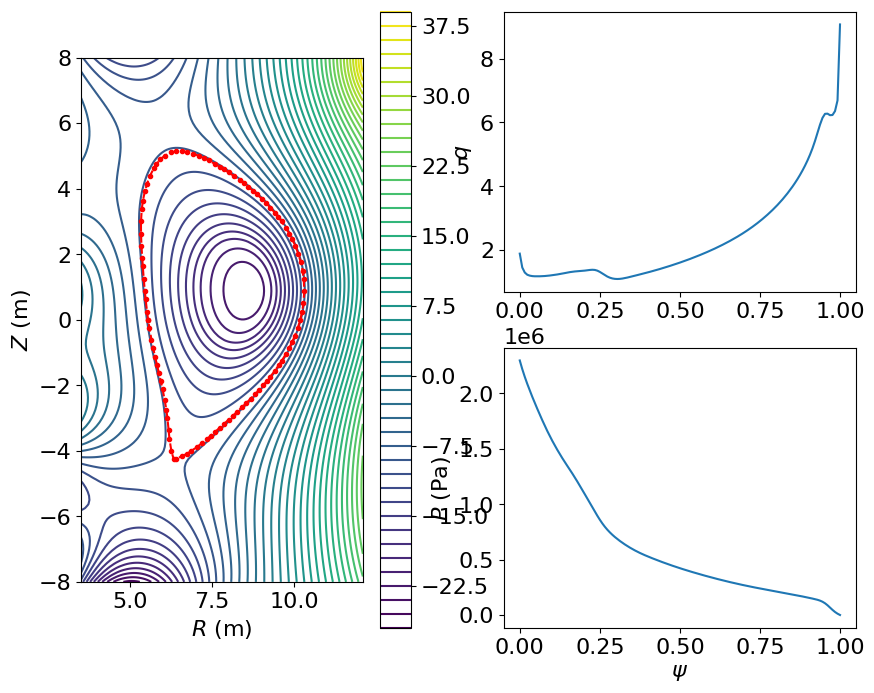

In [4]:
   
filename = './gfile_efit'

g1 = geqdsk(filename)

print (g1.__doc__)
print ('g-function')
print (g1.fpol)
print ('pressure')
print (g1.pres)
print ("gg'")
print (g1.ffprime)
print ("p'")
print (g1.pprime)
print ("q")
print (g1.qpsi)
print ("wall boundary (r,z) doublets")
print (g1.getPlasmaGeometry())
print ("limiter geometry  (r,z) doublets")
print (g1.getLimiterGeometry())
print ('       psi             pres            fpol            qpsi')
for i in range(len(g1.qpsi)):
    psi = g1.psimag + float(i)*(g1.psibdy-g1.psimag)/float(g1.nw-1)
    print ('%15.6f %15.6f %15.6f %15.6f' % (psi, g1.pres[i], g1.fpol[i], g1.qpsi[i]))
g1.plot()




In [7]:
print(g1.nw)

129


In [9]:
psi1d=numpy.linspace(0,1,g1.nw)

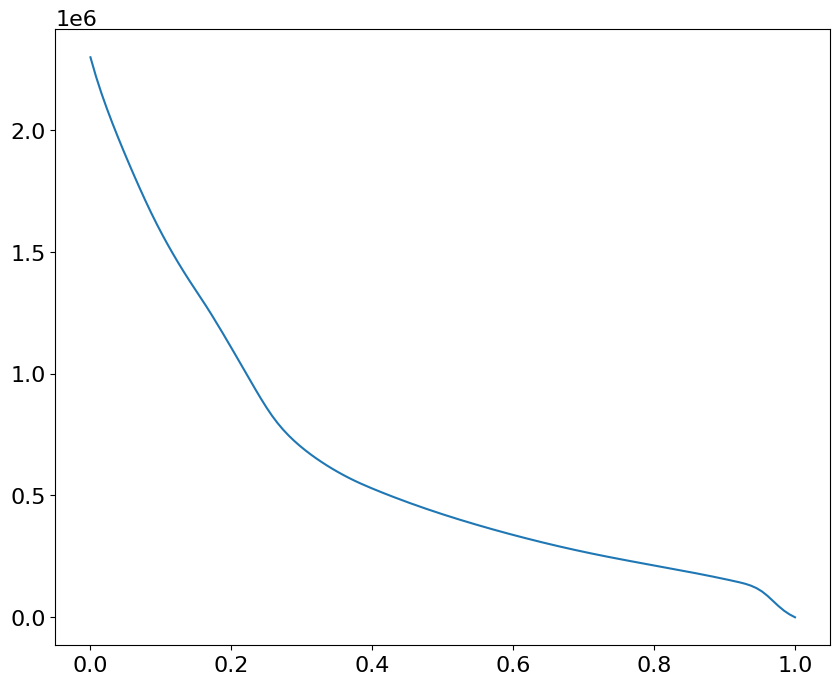

CSV data points: 129
gfile data points: 129
Both have same number of points: True
Saved: pressure_comparison_same_norm.png
\nMax difference: 0.00 Pa = 0.000000 MPa
Mean difference: 0.00 Pa
Max pressure: 2297440.58 Pa


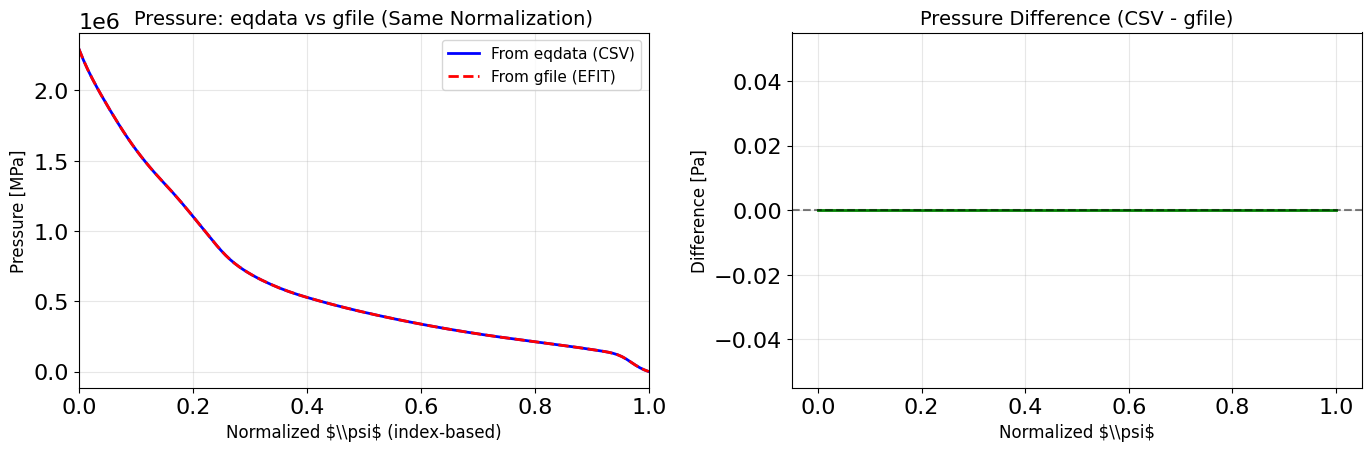

In [49]:
import numpy as np
import matplotlib.pyplot as plt
import re
import pandas as pd
# ===== 1. Read pressure from CSV (eqdata) - use index-based normalization =====
csv_data = np.genfromtxt('../eqdata_1D_profiles.csv', delimiter=',', skip_header=1)
ppps_csv = csv_data[:, 2]     # PPPS - pressure [Pa]
nps_csv = len(ppps_csv)
# Use same normalization as gfile: linspace(0, 1, n)
psi_csv_norm = np.linspace(0, 1, nps_csv)

# ===== 2. Read pressure from gfile (same as notebook) =====


gfile_path = '/Users/dengxiaoya/TASK/latest/task/eq/in/gfile_efit'

pres_gfile=g1.pres
psi_gfile = np.linspace(0, 1, nw)  # normalized psi [0, 1]

print(f'CSV data points: {nps_csv}')
print(f'gfile data points: {nw}')
print(f'Both have same number of points: {nps_csv == nw}')

# ===== 3. Plot both together with same normalization =====
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Overlay comparison
ax1 = axes[0]
ax1.plot(psi_csv_norm, np.array(ppps_csv) , 'b-', linewidth=2, label='From eqdata (CSV)')
ax1.plot(psi_gfile, pres_gfile , 'r--', linewidth=2, label='From gfile (EFIT)')
ax1.set_xlabel(r'Normalized \$\\psi\$ (index-based)', fontsize=12)
ax1.set_ylabel('Pressure [MPa]', fontsize=12)
ax1.set_title('Pressure: eqdata vs gfile (Same Normalization)', fontsize=14)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 1)

# Right: Difference plot
ax2 = axes[1]
# Interpolate to same grid for comparison
if nps_csv != nw:
    pres_csv_interp = np.interp(psi_gfile, psi_csv_norm, ppps_csv)
else:
    pres_csv_interp = ppps_csv
    
diff = np.array(pres_csv_interp) - pres_gfile
ax2.plot(psi_gfile, diff, 'g-', linewidth=2)
ax2.axhline(y=0, color='k', linestyle='--', alpha=0.5)
ax2.set_xlabel(r'Normalized \$\\psi\$', fontsize=12)
ax2.set_ylabel('Difference [Pa]', fontsize=12)
ax2.set_title('Pressure Difference (CSV - gfile)', fontsize=14)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pressure_comparison_same_norm.png', dpi=150, bbox_inches='tight')
print('Saved: pressure_comparison_same_norm.png')

# Statistics
print(f'\\nMax difference: {np.abs(diff).max():.2f} Pa = {np.abs(diff).max()/1e6:.6f} MPa')
print(f'Mean difference: {np.abs(diff).mean():.2f} Pa')
print(f'Max pressure: {max(pres_gfile):.2f} Pa')
